# Recipe 3 — Impose an asset's mean, volatility or shape

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/recipes/r3_asset_targets.ipynb)

A capital-market assumption on one fund, a volatility from a risk model, a tail you have measured elsewhere.

<a id="toc"></a>
## Contents

| | |
|---|---|
| **[1. The base](#s1)** | eight funds, six factors, nothing imposed |
| **[2. The order of the rule](#s2)** | why the betas come first |
| **[3. What you give](#s3)** | three cells in the assets sheet |
| **[4. Where the difference goes](#s4)** | the residual |
| **[5. Check](#s5)** | the four moments in the scenarios |
| **[6. What is refused](#s6)** | a volatility below the betas, a shape no residual can carry |
| **[Where to look next](#next)** | the other recipes and the derivations |

---

<a id="s1"></a>
## 1. The base

<sub>[back to contents](#toc)</sub>

Eight funds, six factors, nothing imposed.

The base is `examples/inputs/recipe_base.xlsx`: eight funds, six factors, and
not one number imposed. Every mean, volatility, shape and beta below comes
from the monthly histories since June 2007.

`tags` says which factors each class may load on. `fit` means regressed, an
empty cell means a beta of zero, and the four other sheets are empty.

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_universe.csv: 232 months, 2007-06 to 2026-09
factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
FactorMarket(8 assets on 6 factors, generator='fleishman', 0 assets without history, 0 factors without history)


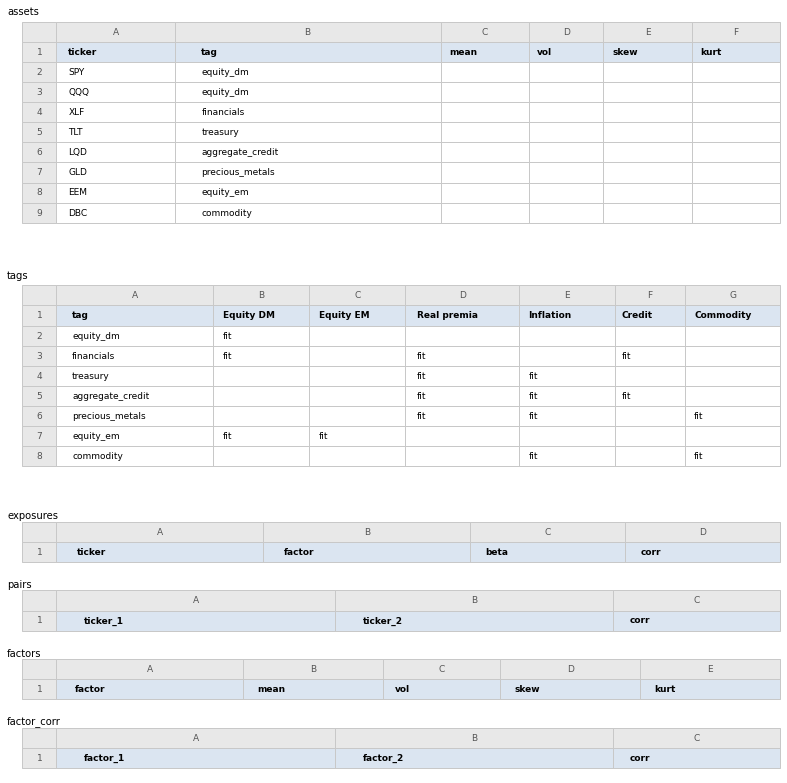

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 200)

ROOT = os.getcwd()                                   # the repo root, from wherever the notebook is opened
while not os.path.isdir(os.path.join(ROOT, "cvinemarketgen")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
try:
    import cvinemarketgen
except ImportError:                                  # Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mamadouyamar/CVineMarketGen.git", "openpyxl"], check=True)
    import cvinemarketgen
from cvinemarketgen import load_etf_monthly, load_factor_data, MarketSpec, FactorMarket, show_workbook, show_change, show_sheet

FACTORS = ["Equity DM", "Equity EM", "Real premia", "Inflation", "Credit", "Commodity"]
A = lambda m: m * 1200                               # monthly mean -> percent a year
V = lambda v: v * np.sqrt(12) * 100                  # monthly vol  -> percent a year
spec = MarketSpec.read(os.path.join(ROOT, "examples", "inputs", "recipe_base.xlsx"))
tick = list(spec.assets["ticker"])
R = load_etf_monthly(tick, start="2007-04", cache=os.path.join(ROOT, "data", "etf_cache_universe.csv"))[tick]
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv"))[FACTORS]
idx = R.index.intersection(F.index); R, F = R.loc[idx], F.loc[idx]
sim = FactorMarket(R, F, spec, generator="fleishman").fit()
print(sim)
show_workbook(spec, max_rows=8)

Eight assets on six factors, all from the histories. The generator is
Fleishman, which fits in a second; notebook 03 uses the C-vine, which takes
the tail dependence of the factors with it.

---

<a id="s2"></a>
## 2. The order of the rule

<sub>[back to contents](#toc)</sub>

Why the betas come first.

An asset is the factors it carries plus an independent residual, so a moment
you impose is delivered by the residual, not by the asset:

$$
\sigma_e^2 = v^2 - \boldsymbol\beta' \boldsymbol\Sigma_f \boldsymbol\beta ,
\qquad
\kappa_{3,e} = s\,v^3 - \kappa_3(\boldsymbol\beta' \mathbf f) ,
\qquad
\kappa_{4,e} = (k - 3)\,v^4 - \kappa_4(\boldsymbol\beta' \mathbf f) ,
\qquad
\alpha = m - \boldsymbol\beta' \boldsymbol\mu_f ,
$$

with $m, v, s, k$ the mean, volatility, skewness and kurtosis you gave.
Cumulants of independent terms add, which is what makes the shape line work.

The order is fixed: betas, then volatility, then shape, then the mean. The
residual's scale needs the betas, and its shape needs the scale.

---

<a id="s3"></a>
## 3. What you give

<sub>[back to contents](#toc)</sub>

Three cells in the assets sheet.

The sheet as it stands: a ticker and a tag, every moment empty.

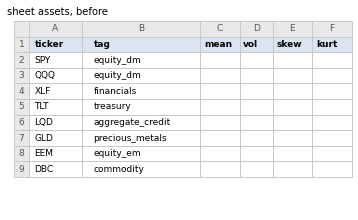

In [2]:
show_sheet(spec.assets, "sheet assets, before", max_rows=10)

A mean for SPY, a volatility for TLT, a shape for GLD. Annual, as every moment
in the workbook is.

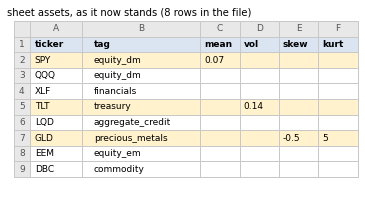

In [3]:
rows = [{"ticker": "SPY", "mean": 0.07}, {"ticker": "TLT", "vol": 0.14}, {"ticker": "GLD", "skew": -0.5, "kurt": 5.0}]
spec_3 = spec
for r_ in rows:
    spec_3 = spec_3.add("assets", r_)
show_change(spec_3, "assets", rows, max_rows=10)

The three rows keep their place in the file and their tags; only the cells
given are written.

---

<a id="s4"></a>
## 4. Where the difference goes

<sub>[back to contents](#toc)</sub>

The residual.

The report names the source of every moment and the residual the rule ended up with.

In [4]:
sim_3 = sim.with_spec(spec_3)
show = ["SPY", "TLT", "GLD"]
pd.concat([sim_3.report.loc[show, ["mean source", "vol source", "skew source", "kurt source"]],
           pd.DataFrame({"resid vol (%/yr)": V(sim_3.model.resid_vol[show]), "base resid vol (%/yr)": V(sim.model.resid_vol[show]),
                         "resid skew": sim_3.report.loc[show, "resid skew"].astype(float),
                         "resid kurt": sim_3.report.loc[show, "resid kurt"].astype(float)}).round(2)], axis=1)

,mean source,vol source,skew source,kurt source,resid vol (%/yr),base resid vol (%/yr),resid skew,resid kurt
SPY,workbook,history (residual),history (residual),history (residual),4.03,4.03,-0.19,3.17
TLT,history (alpha),workbook,history (residual),history (residual),4.38,4.78,0.82,6.96
GLD,history (alpha),history (residual),workbook,workbook,14.55,14.55,-0.71,6.87


SPY's residual is untouched at 4.03 percent a year, because a mean is absorbed
by the alpha alone. TLT's target of 14 percent is below what its betas and its
sample residual produce, so its residual falls from 4.78 to 4.38. GLD's
residual carries the whole shape: skewness -0.71 and kurtosis 6.87 for an
asset asked for -0.5 and 5.0, since the residual is two thirds of its
variance.

---

<a id="s5"></a>
## 5. Check

<sub>[back to contents](#toc)</sub>

The four moments in the scenarios.

Simulate once and read the given moments against the simulated ones.

In [5]:
X3 = sim_3.simulate(40000, seed=5)
c3 = sim_3.check(X3)["assets"].loc[show]
pd.DataFrame({"mean asked": A(c3["mean target"].astype(float)), "mean simulated": A(c3["mean simulated"].astype(float)),
              "vol asked": V(c3["vol target"].astype(float)), "vol simulated": V(c3["vol simulated"].astype(float)),
              "skew asked": c3["skew target"].astype(float), "skew simulated": c3["skew simulated"].astype(float),
              "kurt asked": c3["kurt target"].astype(float), "kurt simulated": c3["kurt simulated"].astype(float)}).round(2)

,mean asked,mean simulated,vol asked,vol simulated,skew asked,skew simulated,kurt asked,kurt simulated
SPY,7.00,6.91,15.55,15.59,NaN,-0.56,NaN,4.37
TLT,3.83,3.95,14.00,14.07,NaN,-0.22,NaN,4.76
GLD,10.60,10.67,17.49,17.47,-0.5,-0.53,5.0,5.31


A shape is not delivered to the precision of a mean. Four seeds show how wide
the landing zone is.

In [6]:
pd.DataFrame({f"seed {sd}": [x.skew(), x.kurtosis() + 3] for sd in (5, 6, 7, 8) for x in [sim_3.simulate(40000, seed=sd)["GLD"]]},
             index=["skewness", "kurtosis"]).round(2)

,seed 5,seed 6,seed 7,seed 8
skewness,-0.53,-0.46,-0.52,-0.45
kurtosis,5.31,4.73,4.90,4.55


The mean and the volatility land within a tenth of a percent a year. The shape
does not: over four seeds GLD's skewness runs -0.45 to -0.53 and its kurtosis
4.55 to 5.31, for -0.5 and 5.0 asked. Read a given shape as a target to within
about a tenth in skewness and half a point in kurtosis.

---

<a id="s6"></a>
## 6. What is refused

<sub>[back to contents](#toc)</sub>

A volatility below the betas, a shape no residual can carry.

The residual variance and the residual cumulants are differences, so a target
can ask for a negative variance or for a shape outside the Johnson SU family.
Both are refused with the numbers that make them infeasible.

In [7]:
for label, row in [("XLF at 6% a year", {"ticker": "XLF", "vol": 0.06}),
                   ("GLD flat: skew -0.5, kurt 3", {"ticker": "GLD", "skew": -0.5, "kurt": 3.0}),
                   ("SPY skew -2.5, kurt 6", {"ticker": "SPY", "skew": -2.5, "kurt": 6.0})]:
    try:
        sim.with_spec(spec.add("assets", row)); print(label, "-> accepted\n")
    except ValueError as err:
        print(label, "-> refused:", err, "\n")

XLF at 6% a year -> refused: asset 'XLF': the betas alone give a volatility of 19.3% a year, above the target 6.0%; largest contributors Equity DM (beta 1.30), Real premia (beta -0.85). Lower them or raise the volatility 

GLD flat: skew -0.5, kurt 3 -> refused: asset 'GLD': the shape you gave (skew -0.50, kurt 3.00) would need a residual with skew -0.7 and kurt 2.7, which no Johnson SU has; the residual is only 69% of the variance and the factors already give the asset skew -0.09 and kurtosis 3.15. Give a shape closer to the factors', or lower the exposures 

SPY skew -2.5, kurt 6 -> refused: asset 'SPY': the shape you gave (skew -2.50, kurt 6.00) would need a residual with skew -112.3 and kurt 370.8, which no Johnson SU has; the residual is only 7% of the variance and the factors already give the asset skew -0.55 and kurtosis 4.35. Give a shape closer to the factors', or lower the exposures 



XLF's betas alone give 19.3 percent a year, so a target of 6 leaves the
residual a negative variance. GLD asked to be flatter than its factors make it
needs a residual kurtosis of 2.7, which no Johnson SU has. SPY's residual is 7
percent of its variance, so a skewness of -2.5 would need -112 from it: the
more of an asset the factors explain, the less of its shape you can set.

---

<a id="next"></a>
## Where to look next

<sub>[back to contents](#toc)</sub>

The whole universe in one file, fitted, checked and written out:
[notebook 03](../03_many_assets_factors.ipynb). The derivations, the feasible
shapes and the bounds: the methods note, `docs/methods-note.pdf`.

The other levers:

- [what an asset loads on](r1_exposures.ipynb)
- [a fund with no history](r2_asset_without_history.ipynb)
- [a correlation between two assets](r4_pair_correlation.ipynb)
- [a view on a factor](r5_factor_views.ipynb)
- [a factor with no history](r6_factor_without_history.ipynb)